In [220]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tqdm import tqdm

In [221]:
BASE_PATH = "/kaggle/input/raabindata-nucleus-cytoplasm-ground-truths/GrTh"

IMAGE_PATH = BASE_PATH + "/Original"
MASK_PATH  = BASE_PATH + "/Ground Truth"

In [222]:
def dice_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    return (2. * intersection) / (pred.sum() + gt.sum() + 1e-8)

def iou_score(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / (union + 1e-8)

In [223]:
def get_boundary(mask):
    mask = mask.astype(np.uint8)
    kernel = np.ones((3,3), np.uint8)
    eroded = cv2.erode(mask, kernel, iterations=1)
    boundary = mask - eroded
    return boundary

def boundary_f1_score(pred, gt):
    pred_boundary = get_boundary(pred)
    gt_boundary = get_boundary(gt)
    
    tp = np.logical_and(pred_boundary, gt_boundary).sum()
    fp = np.logical_and(pred_boundary, np.logical_not(gt_boundary)).sum()
    fn = np.logical_and(np.logical_not(pred_boundary), gt_boundary).sum()
    
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    
    return 2 * precision * recall / (precision + recall + 1e-8)

In [224]:
def preprocess(image_path, mask_path, size=(256,256)):
    image = cv2.imread(image_path)
    image = cv2.resize(image, size)

    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, size)
    mask = (mask > 127).astype(np.uint8)

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    lab = lab.astype(np.float32)

    features = lab[:,:,1:3]   # Use only A & B channels
    features = features / 255.0

    return features, mask

In [225]:
def kmeans_segmentation(image, k=3):
    h, w, c = image.shape
    pixels = image.reshape(-1, 2)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)

    return labels.reshape(h, w)

In [226]:
def fcm_segmentation(image, c=3, m=2, max_iter=100, error=1e-5):
    h, w, ch = image.shape
    X = image.reshape(-1, 2)
    N = X.shape[0]

    U = np.random.rand(c, N)
    U = U / np.sum(U, axis=0, keepdims=True)

    for _ in range(max_iter):
        U_old = U.copy()

        centers = (U ** m) @ X / np.sum(U ** m, axis=1, keepdims=True)

        dist = np.zeros((c, N))
        for i in range(c):
            dist[i] = np.linalg.norm(X - centers[i], axis=1)

        dist = np.fmax(dist, 1e-8)

        for i in range(c):
            U[i] = 1.0 / np.sum((dist[i] / dist) ** (2 / (m - 1)), axis=0)

        if np.linalg.norm(U - U_old) < error:
            break

    labels = np.argmax(U, axis=0)
    return labels.reshape(h, w)

In [227]:
def extract_nucleus(segmented):
    clusters = np.unique(segmented)

    min_area = 1e9
    nucleus_cluster = 0

    for cluster in clusters:
        area = np.sum(segmented == cluster)
        if area < min_area:
            min_area = area
            nucleus_cluster = cluster

    return (segmented == nucleus_cluster).astype(np.uint8)

In [228]:
def refine_mask(mask):
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

In [229]:
cell_types = ["Basophil", "Eosinophil", "Lymphocyte", "Monocyte", "Neutrophil"]

kmeans_dice = []
kmeans_iou = []
kmeans_boundary = []

fcm_dice = []
fcm_iou = []
fcm_boundary = []

num_samples_per_class = 5   # increase later

for cell in tqdm(cell_types):
    
    img_folder = os.path.join(IMAGE_PATH, cell)
    mask_folder = os.path.join(MASK_PATH, cell)
    
    image_files = sorted(os.listdir(img_folder))[:num_samples_per_class]
    
    for file in image_files:
        
        img_path = os.path.join(img_folder, file)
        mask_path = os.path.join(mask_folder, file)
        
        image, gt_mask = preprocess(img_path, mask_path)

        # ---- KMeans ----
        k_seg = kmeans_segmentation(image)
        k_nucleus = extract_nucleus(k_seg)
        k_nucleus = refine_mask(k_nucleus)

        # ---- FCM ----
        f_seg = fcm_segmentation(image)
        f_nucleus = extract_nucleus(f_seg)
        f_nucleus = refine_mask(f_nucleus)

        # ---- Metrics ----
        kmeans_dice.append(dice_score(k_nucleus, gt_mask))
        kmeans_iou.append(iou_score(k_nucleus, gt_mask))
        kmeans_boundary.append(boundary_f1_score(k_nucleus, gt_mask))

        fcm_dice.append(dice_score(f_nucleus, gt_mask))
        fcm_iou.append(iou_score(f_nucleus, gt_mask))
        fcm_boundary.append(boundary_f1_score(f_nucleus, gt_mask))

100%|██████████| 5/5 [00:28<00:00,  5.71s/it]


In [230]:
print("\n====== FINAL RESULTS ======\n")

print("K-Means Dice:", np.mean(kmeans_dice))
print("K-Means IoU :", np.mean(kmeans_iou))
print("K-Means Boundary F1:", np.mean(kmeans_boundary))

print("\n")

print("FCM Dice:", np.mean(fcm_dice))
print("FCM IoU :", np.mean(fcm_iou))
print("FCM Boundary F1:", np.mean(fcm_boundary))


====== FINAL RESULTS ======

K-Means Dice: 0.34508660214407966
K-Means IoU : 0.2791150280059062
K-Means Boundary F1: 0.248214095694537


FCM Dice: 0.3416597817087715
FCM IoU : 0.2741342592899456
FCM Boundary F1: 0.22532244744202473


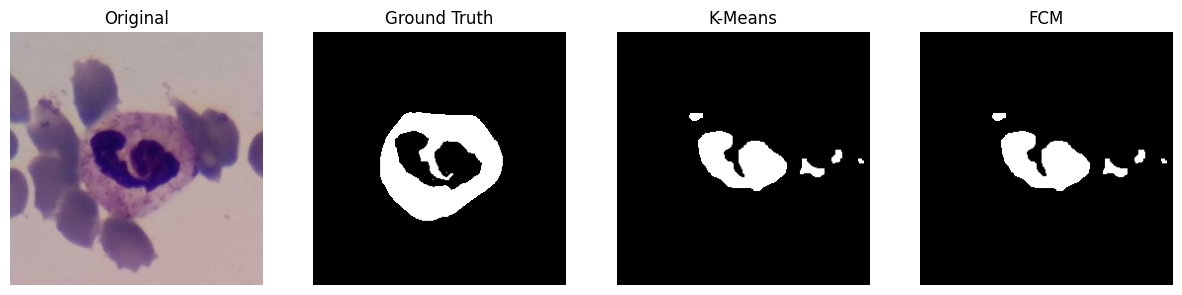

In [231]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt_mask, cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(k_nucleus, cmap='gray')
plt.title("K-Means")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(f_nucleus, cmap='gray')
plt.title("FCM")
plt.axis("off")

plt.show()

**Conclusion:**

In this project, K-Means and Fuzzy C-Means clustering were applied for white blood cell nucleus segmentation using LAB color space features. The experimental results show that both methods produce comparable segmentation performance.

The Dice coefficient and IoU values indicate moderate overlap between predicted masks and ground truth masks. Boundary F1 scores are relatively low due to partial detection of the outer nucleus boundary. In this dataset, FCM did not significantly outperform K-Means because the nucleus and cytoplasm regions are reasonably separable in the chosen feature space, reducing the advantage of soft clustering.

Overall, both hard and soft clustering methods demonstrate similar behavior for this segmentation task. The limitation of clustering-based segmentation is the lack of spatial and shape constraints, which results in incomplete nucleus boundary extraction.